In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import pandas as pd
import itertools
import datetime

# ============================================================
# PARAMETERS (GLOBAL)
# ============================================================
WIDTH = 380
HEIGHT = 280
NUM_VOTERS = 1000
NUM_PARTIES = 4
NUM_DISTRICTS = 8
VOTERS_PER_DISTRICT = NUM_VOTERS // NUM_DISTRICTS
NUM_RUNS = 10
NUM_RESTARTS = 5

POPULATION_TOLERANCE = 0.06  # 6% ± 3% wiggle room
MIN_DISTRICT_SIZE = int(VOTERS_PER_DISTRICT * (1 - (POPULATION_TOLERANCE + 0.03)))
MAX_DISTRICT_SIZE = int(VOTERS_PER_DISTRICT * (1 + (POPULATION_TOLERANCE + 0.03)))

NUM_CITIES = 5
CITY_INTENSITY = (5, 12)
CITY_SPREAD = (10, 30)

np.random.seed(1)

PARTY_IDS = [f"Party {i}" for i in range(NUM_PARTIES)]
party_colors = np.random.rand(NUM_PARTIES, 3)
PARTY_COLORS = dict(zip(PARTY_IDS, party_colors))

# Party distribution bias — must sum to 1
PARTY_BIAS = [0.25, 0.25, 0.25, 0.25]

TARGET_PARTY = "Party 3"

# ============================================================
# GENERATE POPULATION DENSITY
# ============================================================
density = np.full((HEIGHT, WIDTH), 1.0)
X, Y = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))

for _ in range(NUM_CITIES):
    cx = np.random.uniform(0, WIDTH)
    cy = np.random.uniform(0, HEIGHT)
    intensity = np.random.uniform(*CITY_INTENSITY)
    sigma = np.random.uniform(*CITY_SPREAD)
    density += intensity * np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma**2))

# ============================================================
# GENERATE VOTERS BASED ON DENSITY
# ============================================================
flat_density = density.ravel()
flat_density /= flat_density.sum()
indices = np.random.choice(WIDTH * HEIGHT, size=NUM_VOTERS, p=flat_density)
voters_y, voters_x = np.unravel_index(indices, (HEIGHT, WIDTH))
voters = np.column_stack((voters_x, voters_y))

# ============================================================
# FIXED PARTY PREFERENCES (GLOBAL)
# ============================================================
voter_parties = np.random.choice(
    np.arange(NUM_PARTIES),
    size=NUM_VOTERS,
    p=PARTY_BIAS
)
voter_colors = party_colors[voter_parties]


# ============================================================
# DISTRICT GENERATION
# ============================================================

def connected_districts(voters, num_districts, voters_per_district, rng, k_neighbors=20):
    """
    Builds geographically connected districts using BFS seeded from
    well-separated starting points. Validates connectivity before returning.
    Retries automatically on failure, up to 20 attempts.
    """
    N = len(voters)
    tree = cKDTree(voters)
    _, all_neighbors = tree.query(voters, k=min(50, N))

    def is_connected(district, d):
        members = np.where(district == d)[0]
        if len(members) <= 1:
            return True
        member_set = set(members)
        visited = set()
        queue = [members[0]]
        visited.add(members[0])
        while queue:
            cur = queue.pop(0)
            for nb in all_neighbors[cur]:
                if nb in member_set and nb not in visited:
                    visited.add(nb)
                    queue.append(nb)
        return len(visited) == len(members)

    def attempt():
        district = -np.ones(N, dtype=int)
        unassigned = set(range(N))

        # Seed districts from well-separated starting points
        seeds = []
        for d in range(num_districts):
            if not unassigned:
                break
            if d == 0:
                seed = rng.choice(list(unassigned))
            else:
                candidates = list(unassigned)
                cand_pts = voters[candidates]
                seed_pts = voters[seeds]
                dists = np.min(
                    np.linalg.norm(cand_pts[:, None] - seed_pts[None], axis=2),
                    axis=1
                )
                seed = candidates[np.argmax(dists)]
            seeds.append(seed)
            district[seed] = d
            unassigned.remove(seed)

        # BFS grow each district from its seed
        queues = {d: [seeds[d]] for d in range(num_districts)}
        counts = {d: 1 for d in range(num_districts)}

        changed = True
        while unassigned and changed:
            changed = False
            for d in range(num_districts):
                if counts[d] >= voters_per_district:
                    continue
                if not queues[d]:
                    continue
                current = queues[d].pop(0)
                _, neighbors = tree.query(voters[current], k=k_neighbors)
                for n in neighbors:
                    if n in unassigned and counts[d] < voters_per_district:
                        district[n] = d
                        unassigned.remove(n)
                        queues[d].append(n)
                        counts[d] += 1
                        changed = True

        # Assign leftovers to nearest assigned neighbor
        leftover = list(np.where(district == -1)[0])
        if leftover:
            assigned = np.where(district != -1)[0]
            if len(assigned) == 0:
                return None
            assigned_tree = cKDTree(voters[assigned])
            for i in leftover:
                _, idx = assigned_tree.query(voters[i])
                district[i] = district[assigned[idx]]

        if -1 in district:
            return None
        if len(set(district)) < num_districts:
            return None

        # Connectivity check — reject if any district is disconnected
        for d in range(num_districts):
            if not is_connected(district, d):
                return None

        return district

    for _ in range(20):
        result = attempt()
        if result is not None:
            return result

    raise RuntimeError("Could not generate valid connected districts after 20 attempts.")


# ============================================================
# CONNECTIVITY VALIDATION
# ============================================================

def all_districts_connected(district_labels, num_districts, voters, k=50):
    """
    Final validation after gerrymandering — checks every district for
    connectivity using a dense neighbor graph.
    Rejects even small disconnected fragments.
    """
    N = len(voters)
    tree = cKDTree(voters)
    _, all_neighbors = tree.query(voters, k=min(k, N))

    for d in range(num_districts):
        members = np.where(district_labels == d)[0]
        if len(members) <= 1:
            continue
        member_set = set(members)
        visited = set()
        queue = [members[0]]
        visited.add(members[0])
        while queue:
            cur = queue.pop(0)
            for nb in all_neighbors[cur]:
                if nb in member_set and nb not in visited:
                    visited.add(nb)
                    queue.append(nb)
        if len(visited) != len(members):
            return False
    return True


# ============================================================
# GERRYMANDERING
# ============================================================

def get_district_neighbor_graph(voters, k=10):
    """Precomputes neighbor lookup table once per gerrymander call."""
    tree = cKDTree(voters)
    _, all_neighbors = tree.query(voters, k=k)
    return all_neighbors


def is_district_connected(district_labels, neighbor_index, district_id):
    """
    Checks if all voters in a district form a single connected component.
    Used during swap validation in force_gerrymander.
    """
    members = np.where(district_labels == district_id)[0]
    if len(members) <= 1:
        return True

    member_set = set(members)
    visited = set()
    queue = [members[0]]
    visited.add(members[0])

    while queue:
        current = queue.pop(0)
        for n in neighbor_index[current]:
            if n in member_set and n not in visited:
                visited.add(n)
                queue.append(n)

    return len(visited) == len(members)


def calculate_gerrymander_score(district_counts, target_party, target_seats):
    """
    Packing and cracking score:
      - Large bonus for hitting target_seats
      - Per-seat bonus to protect existing wins
      - Rewards efficient wins, penalizes losses
    """
    current_wins = sum(1 for d in district_counts if get_is_winner(d, target_party))
    score = 0

    if current_wins >= target_seats:
        score += 10000

    score += current_wins * 2000

    for counts in district_counts:
        t_votes = counts[target_party]
        others = [v for p, v in counts.items() if p != target_party]
        max_opp = max(others) if others else 0
        margin = t_votes - max_opp
        if margin > 0:
            score += 1000 - (margin * 0.5)
        else:
            score += margin * 2

    return score


def force_gerrymander(voters, initial_labels, target_party, target_seats, iterations=2000, k=10):
    """
    Optimizes district boundaries to favor target_party via hill-climbing.
    Enforces connectivity on both districts involved in each swap.
    Enforces population balance within tolerance on each swap.
    Failed runs are filtered in the main loop.
    """
    current_labels = initial_labels.copy()
    neighbor_index = get_district_neighbor_graph(voters, k=k)
    N = len(voters)

    # Build border set
    border_set = set()
    for i in range(N):
        if any(current_labels[n] != current_labels[i] for n in neighbor_index[i]):
            border_set.add(i)

    current_counts = count_votes(current_labels)
    current_score = calculate_gerrymander_score(current_counts, target_party, target_seats)

    for _ in range(iterations):
        if not border_set:
            break

        v_idx = np.random.choice(list(border_set))
        old_dist = current_labels[v_idx]

        neighbor_dists = set(
            current_labels[n]
            for n in neighbor_index[v_idx]
            if current_labels[n] != old_dist
        )
        if not neighbor_dists:
            border_set.discard(v_idx)
            continue

        new_dist = np.random.choice(list(neighbor_dists))

        # Reject if swap would empty old district
        if np.sum(current_labels == old_dist) <= 1:
            continue

        # Population balance check before swap
        old_size = np.sum(current_labels == old_dist)
        new_size = np.sum(current_labels == new_dist)
        if (old_size - 1) < MIN_DISTRICT_SIZE or (new_size + 1) > MAX_DISTRICT_SIZE:
            continue

        # Tentative swap
        current_labels[v_idx] = new_dist

        # Connectivity check on both districts
        if not is_district_connected(current_labels, neighbor_index, old_dist) or \
                not is_district_connected(current_labels, neighbor_index, new_dist):
            current_labels[v_idx] = old_dist
            continue

        # Score check — only accept improvements
        new_counts = count_votes(current_labels)
        new_score = calculate_gerrymander_score(new_counts, target_party, target_seats)

        if new_score > current_score:
            current_score = new_score
            if all(current_labels[n] == new_dist for n in neighbor_index[v_idx]):
                border_set.discard(v_idx)
            for n in neighbor_index[v_idx]:
                if any(current_labels[nn] != current_labels[n] for nn in neighbor_index[n]):
                    border_set.add(n)
                else:
                    border_set.discard(n)
        else:
            current_labels[v_idx] = old_dist

    final_counts = count_votes(current_labels)
    seats_won = sum(1 for d in final_counts if get_is_winner(d, target_party))
    return current_labels, seats_won


# ============================================================
# VOTE COUNTING
# ============================================================

def count_votes(district_labels):
    """Returns a list of vote count dicts, one per district."""
    district_counts = []
    for d in range(NUM_DISTRICTS):
        mask = district_labels == d
        counts = {party: 0 for party in PARTY_IDS}
        for i in np.where(mask)[0]:
            counts[PARTY_IDS[voter_parties[i]]] += 1
        district_counts.append(counts)
    return district_counts


# ============================================================
# MEASUREMENT FUNCTIONS
# ============================================================

def efficiency_gap(district_counts):
    """Returns a per-district efficiency gap (multi-party generalization)."""
    district_gaps = []
    for district in district_counts:
        total_votes = sum(district.values())
        if total_votes == 0:
            district_gaps.append(0.0)
            continue
        winning_party = max(district.items(), key=lambda item: item[1])[0]
        num_winning_votes = district[winning_party]
        num_losing_votes = total_votes - num_winning_votes
        wasted_winner = num_winning_votes - (total_votes / NUM_PARTIES)
        wasted_loser = num_losing_votes
        gap = (wasted_winner - wasted_loser) / total_votes
        district_gaps.append(gap)
    return district_gaps


def get_is_winner(district_counts, target_party):
    """Returns True if target_party strictly leads all others."""
    target_votes = district_counts[target_party]
    other_votes = [district_counts[p] for p in district_counts if p != target_party]
    return all(target_votes > v for v in other_votes)


def get_current_vote_share(district_counts, target_party):
    """Returns the statewide vote share of the target party."""
    total = sum(sum(d.values()) for d in district_counts)
    party_total = sum(d[target_party] for d in district_counts)
    return party_total / total


# ============================================================
# SEAT-VOTE CURVE
# ============================================================

def simulate_vote_shifts_forward(district_counts, target_party, PARTY_IDS, NUM_DISTRICTS):
    """
    Shifts votes toward target_party by taking from the weakest competitor
    in each district one step at a time.
    """
    counts = [d.copy() for d in district_counts]
    competitors = [p for p in PARTY_IDS if p != target_party]
    num_competitors = len(competitors)

    def count_wins():
        return sum(1 for d in counts if get_is_winner(d, target_party))

    current_wins = count_wins()
    history = []

    while True:
        any_shift = False
        for d in counts:
            active_competitors = sorted(
                [p for p in competitors if d[p] > 0],
                key=lambda p: (d[p], p)
            )
            if active_competitors:
                from_party = active_competitors[0]
                actual_taken = min(d[from_party], num_competitors)
                if actual_taken > 0:
                    d[from_party] -= actual_taken
                    d[target_party] += actual_taken
                    any_shift = True

        new_wins = count_wins()
        if new_wins > current_wins:
            vote_share = sum(d[target_party] for d in counts) / sum(sum(d.values()) for d in counts)
            history.append({"districts_won": new_wins, "vote_share": vote_share})
            current_wins = new_wins

        if not any_shift or new_wins == NUM_DISTRICTS:
            break

    return {"history": history, "initial_wins": count_wins(), "initial_vote_share": 0}


def simulate_vote_shifts_backward(district_counts, target_party, PARTY_IDS):
    """
    Shifts votes away from target_party toward the strongest competitor
    in each district one step at a time.
    """
    counts = [d.copy() for d in district_counts]
    competitors = [p for p in PARTY_IDS if p != target_party]
    num_competitors = len(competitors)

    def count_wins():
        return sum(1 for d in counts if get_is_winner(d, target_party))

    current_wins = count_wins()
    history = []

    while True:
        any_shift = False
        for d in counts:
            ranked_competitors = sorted(
                competitors,
                key=lambda p: (d[p], p),
                reverse=True
            )
            strongest_competitor = ranked_competitors[0]
            to_move = min(d[target_party], num_competitors)
            if to_move > 0:
                d[target_party] -= to_move
                d[strongest_competitor] += to_move
                any_shift = True

        new_wins = count_wins()
        if new_wins < current_wins:
            vote_share = sum(d[target_party] for d in counts) / sum(sum(d.values()) for d in counts)
            history.append({"districts_won": new_wins, "vote_share": vote_share})
            current_wins = new_wins

        if not any_shift or new_wins == 0:
            break

    return {"history": history, "initial_wins": count_wins(), "initial_vote_share": 0}


def compute_step_curve_for_party(district_counts, target_party, PARTY_IDS, NUM_DISTRICTS):
    """
    Builds the full seat-vote step curve for a given party by merging
    forward and backward vote shift histories.
    """
    initial_vote = get_current_vote_share(district_counts, target_party)
    initial_wins = sum(1 for d in district_counts if get_is_winner(d, target_party))
    fwd = simulate_vote_shifts_forward(district_counts, target_party, PARTY_IDS, NUM_DISTRICTS)
    rev = simulate_vote_shifts_backward(district_counts, target_party, PARTY_IDS)
    base_point = (initial_vote, initial_wins)
    fwd_points = [base_point] + [(h["vote_share"], h["districts_won"]) for h in fwd["history"]]
    rev_points = [base_point] + [(h["vote_share"], h["districts_won"]) for h in rev["history"]]
    merged = sorted(set(fwd_points + rev_points))
    return merged


# ============================================================
# AREA METRICS
# ============================================================

def compute_step_function_area(step_points, num_districts):
    """
    Computes the geometric area between the seat-vote curve and its complement.

    Returns:
        dict with keys: area_between, area_step, area_complement
    """
    points = sorted(step_points, key=lambda x: x[0])
    if points[0][0] > 0:
        points = [(0, 0)] + points
    if points[-1][0] < 1.0:
        points = points + [(1.0, points[-1][1])]

    step_x, step_y = zip(*points)
    step_x = np.array(step_x)
    step_y = np.array(step_y) / num_districts

    complement_x = 1 - step_x[::-1]
    complement_y = 1 - step_y[::-1]
    all_x = np.unique(np.concatenate([step_x, complement_x]))

    area_between = 0.0
    area_step = 0.0
    area_complement = 0.0

    def step_value_at(x, xs, ys):
        idx = np.searchsorted(xs, x, side='right') - 1
        return ys[max(0, idx)]

    for i in range(len(all_x) - 1):
        x1, x2 = all_x[i], all_x[i + 1]
        width = x2 - x1
        midpoint = (x1 + x2) / 2
        f_val = step_value_at(midpoint, step_x, step_y)
        g_val = step_value_at(midpoint, complement_x, complement_y)
        area_between += width * abs(f_val - g_val)
        area_step += width * f_val
        area_complement += width * g_val

    return {"area_between": area_between, "area_step": area_step, "area_complement": area_complement}


def compute_pairwise_area(curve1, curve2, num_districts):
    """
    Computes the absolute area between the step curves of two parties.
    Integral of |f(x) - g(x)| dx over [0, 1].
    """
    x1, y1 = zip(*sorted(curve1))
    x2, y2 = zip(*sorted(curve2))
    y1 = np.array(y1) / num_districts
    y2 = np.array(y2) / num_districts

    all_x = np.unique(np.concatenate([x1, x2]))
    if all_x[0] > 0:
        all_x = np.insert(all_x, 0, 0.0)
    if all_x[-1] < 1:
        all_x = np.append(all_x, 1.0)

    def get_val(x, xs, ys):
        idx = np.searchsorted(xs, x, side='right') - 1
        return ys[max(0, idx)]

    total_area = 0.0
    for i in range(len(all_x) - 1):
        mid = (all_x[i] + all_x[i+1]) / 2
        width = all_x[i+1] - all_x[i]
        diff = abs(get_val(mid, x1, y1) - get_val(mid, x2, y2))
        total_area += width * diff
    return total_area


# ============================================================
# EXCEL EXPORT
# ============================================================

def export_full_simulation_data(all_district_counts, all_step_curves, PARTY_IDS):
    """
    Exports simulation results to a timestamped Excel file with sheets:
      - District_Details: per-district vote counts and winners
      - Efficiency_Gaps:  efficiency gap per party per run
      - Pairwise_Areas:   area gap between each party pair per run
      - Summary_Stats:    mean, std, max of pairwise areas
    """
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
    filename = f"Gerrymandering_Results_{timestamp}.xlsx"
    print(f"\nGathering data and exporting to {filename}...")

    # Sheet 1: District-level winners and vote counts
    dist_rows = []
    for run_idx, run_counts in enumerate(all_district_counts):
        for d_idx, counts in enumerate(run_counts):
            winner = max(counts, key=counts.get)
            row = {"Run": run_idx + 1, "District": d_idx + 1, "Winner": winner}
            for p in PARTY_IDS:
                row[f"{p}_Votes"] = counts[p]
            dist_rows.append(row)
    df_districts = pd.DataFrame(dist_rows)

    # Sheet 2: Efficiency gaps
    gap_rows = []
    for run_idx, district_counts in enumerate(all_district_counts):
        wasted = {p: 0 for p in PARTY_IDS}
        total_v = 0
        for d in district_counts:
            d_total = sum(d.values())
            total_v += d_total
            sorted_v = sorted(d.values(), reverse=True)
            winner_p = max(d, key=d.get)
            needed = sorted_v[1] + 1 if len(sorted_v) > 1 else (d_total // 2) + 1
            for p in PARTY_IDS:
                if p == winner_p:
                    wasted[p] += max(0, d[p] - needed)
                else:
                    wasted[p] += d[p]
        for p in PARTY_IDS:
            others_wasted = sum(v for k, v in wasted.items() if k != p)
            gap_val = (wasted[p] - others_wasted) / total_v
            gap_rows.append({"Run": run_idx + 1, "Party": p, "Efficiency_Gap": gap_val})
    df_eff = pd.DataFrame(gap_rows)

    # Sheet 3: Pairwise area differences
    pair_rows = []
    party_pairs = list(itertools.combinations(PARTY_IDS, 2))
    num_districts = len(all_district_counts[0])
    for run_idx in range(len(all_step_curves)):
        current_curves = all_step_curves[run_idx]
        for p1, p2 in party_pairs:
            area_gap = compute_pairwise_area(current_curves[p1], current_curves[p2], num_districts)
            pair_rows.append({"Run": run_idx + 1, "Comparison": f"{p1} vs {p2}", "Area_Gap": area_gap})
    df_areas = pd.DataFrame(pair_rows)

    try:
        with pd.ExcelWriter(filename, engine='openpyxl') as writer:
            df_districts.to_excel(writer, sheet_name='District_Details', index=False)
            df_eff.to_excel(writer, sheet_name='Efficiency_Gaps', index=False)
            df_areas.to_excel(writer, sheet_name='Pairwise_Areas', index=False)
            summary = df_areas.groupby("Comparison")["Area_Gap"].agg(['mean', 'std', 'max']).reset_index()
            summary.to_excel(writer, sheet_name='Summary_Stats', index=False)
        print(f"Success! Saved {len(df_districts)} district rows to Excel.")
    except PermissionError:
        print(f"ERROR: Could not save. Please close '{filename}' if open in Excel and try again.")


# ============================================================
# PLOTTING
# ============================================================

def build_bg_image(voters, district_labels, num_districts, grid_step=4):
    """Builds a pixel-grid background image colored by district."""
    district_cmap = plt.cm.get_cmap('tab10', num_districts)
    gx = np.arange(0, WIDTH, grid_step)
    gy = np.arange(0, HEIGHT, grid_step)
    grid_x, grid_y = np.meshgrid(gx, gy)
    grid_points = np.column_stack([grid_x.ravel(), grid_y.ravel()])
    tree = cKDTree(voters)
    _, nearest_voter = tree.query(grid_points)
    grid_districts = district_labels[nearest_voter].reshape(grid_x.shape)
    bg_image = np.zeros((*grid_districts.shape, 3))
    for d in range(num_districts):
        bg_image[grid_districts == d] = district_cmap(d)[:3]
    return bg_image, district_cmap


def plot_maps(n_maps, all_starting_labels, all_gerrymandered_labels,
              voters, voter_parties, party_colors, PARTY_IDS, NUM_DISTRICTS):
    """
    Plots the last n_maps successful runs side by side.
    Left:  fair starting map
    Right: gerrymandered map

    Usage:
        plot_maps(3, all_starting_labels_successful, all_gerrymandered_labels,
                  voters, voter_parties, party_colors, PARTY_IDS, NUM_DISTRICTS)
    """
    n = min(n_maps, len(all_gerrymandered_labels))
    indices = list(range(len(all_gerrymandered_labels) - n, len(all_gerrymandered_labels)))

    for idx in indices:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        fair_labels = all_starting_labels[idx]
        gerry_labels = all_gerrymandered_labels[idx]

        fair_bg, district_cmap = build_bg_image(voters, fair_labels, NUM_DISTRICTS)
        gerry_bg, _ = build_bg_image(voters, gerry_labels, NUM_DISTRICTS)

        fair_counts = count_votes(fair_labels)
        gerry_counts = count_votes(gerry_labels)

        fair_seats = sum(1 for d in fair_counts if get_is_winner(d, TARGET_PARTY))
        gerry_seats = sum(1 for d in gerry_counts if get_is_winner(d, TARGET_PARTY))

        # Left: fair map
        ax1 = axes[0]
        ax1.imshow(fair_bg, origin='lower', extent=[0, WIDTH, 0, HEIGHT],
                   alpha=0.25, aspect='auto')
        for d in range(NUM_DISTRICTS):
            mask = fair_labels == d
            winner = max(fair_counts[d], key=fair_counts[d].get)
            ax1.scatter(voters[mask, 0], voters[mask, 1],
                        color=district_cmap(d), s=10, alpha=0.8,
                        label=f"D{d+1} → {winner}")
        ax1.set_title(f"Fair Map — {TARGET_PARTY} wins {fair_seats} seats")
        ax1.set_xlim(0, WIDTH)
        ax1.set_ylim(0, HEIGHT)
        ax1.legend(markerscale=2, fontsize=8, loc='lower left')
        ax1.set_aspect('equal')
        ax1.axis('off')

        # Right: gerrymandered map
        ax2 = axes[1]
        ax2.imshow(gerry_bg, origin='lower', extent=[0, WIDTH, 0, HEIGHT],
                   alpha=0.25, aspect='auto')
        for d in range(NUM_DISTRICTS):
            mask = gerry_labels == d
            winner = max(gerry_counts[d], key=gerry_counts[d].get)
            ax2.scatter(voters[mask, 0], voters[mask, 1],
                        color=district_cmap(d), s=10, alpha=0.8,
                        label=f"D{d+1} → {winner}")
        ax2.set_title(f"Gerrymandered Map — {TARGET_PARTY} wins {gerry_seats} seats")
        ax2.set_xlim(0, WIDTH)
        ax2.set_ylim(0, HEIGHT)
        ax2.legend(markerscale=2, fontsize=8, loc='lower left')
        ax2.set_aspect('equal')
        ax2.axis('off')

        plt.suptitle(
            f"Successful Run {idx+1} — {TARGET_PARTY}: {fair_seats} seats (fair) "
            f"→ {gerry_seats} seats (gerrymandered)",
            fontsize=12
        )
        plt.tight_layout()
        plt.show()


# ============================================================
# MAIN SIMULATION
# ============================================================

# ---- PHASE 1: FAIR SIMULATION ----
print("Running fair simulation to establish baseline...")
fair_seat_counts = []
all_starting_labels = []

for run in range(NUM_RUNS):
    rng = np.random.default_rng()
    starting_labels = connected_districts(
        voters, NUM_DISTRICTS, VOTERS_PER_DISTRICT, rng
    )
    all_starting_labels.append(starting_labels.copy())
    district_counts = count_votes(starting_labels)
    seats_won = sum(1 for d in district_counts if get_is_winner(d, TARGET_PARTY))
    fair_seat_counts.append(seats_won)

baseline_seats = round(np.mean(fair_seat_counts))
target_seats = baseline_seats + 1
print(f"Fair baseline: {TARGET_PARTY} wins ~{baseline_seats} seats on average.")
print(f"Gerrymandering target: {target_seats} seats.")

# ---- PHASE 2: GERRYMANDERED SIMULATION WITH FILTERING ----
print("\nRunning gerrymandered simulation...")

all_efficiency_gaps = []
all_pr_vote_shares = []
all_pr_seat_shares = []
all_district_counts = []
all_area_results = []
all_step_curves = []
all_gerrymandered_labels = []
all_starting_labels_successful = []
all_pairwise_areas = []
all_step_curves_random =[]
all_district_df = None

total_discarded = 0
total_successful = 0

for run in range(NUM_RUNS):
    fair_seats = fair_seat_counts[run]

    # Multiple restarts — keep best result that passes connectivity validation
    best_labels = None
    best_seats = -1
    best_starting = None

    for restart in range(NUM_RESTARTS):
        rng = np.random.default_rng()
        starting_labels = connected_districts(
            voters, NUM_DISTRICTS, VOTERS_PER_DISTRICT, rng
        )
        labels, seats = force_gerrymander(
            voters, starting_labels, TARGET_PARTY, target_seats
        )

        # Reject if any district is disconnected — even small fragments
        if not all_districts_connected(labels, NUM_DISTRICTS, voters, k=50):
            continue

        if seats > best_seats:
            best_seats = seats
            best_labels = labels
            best_starting = starting_labels

    # Filter: only keep runs that gained at least 1 seat
    if best_labels is None or best_seats <= fair_seats:
        total_discarded += 1
    else:
        total_successful += 1
        all_gerrymandered_labels.append(best_labels.copy())
        all_starting_labels_successful.append(best_starting.copy())

        district_counts = count_votes(best_labels)

        gap = efficiency_gap(district_counts)
        all_efficiency_gaps.append(gap)

        pr_vote_share = {party: 0 for party in PARTY_IDS}
        pr_seat_share = {party: 0 for party in PARTY_IDS}

        for d in district_counts:
            for party in PARTY_IDS:
                pr_vote_share[party] += d[party]

        total_votes = sum(pr_vote_share.values())
        for party in PARTY_IDS:
            pr_vote_share[party] /= total_votes

        for d in district_counts:
            winner = max(d, key=d.get)
            pr_seat_share[winner] += 1
        for party in PARTY_IDS:
            pr_seat_share[party] /= NUM_DISTRICTS

        all_pr_vote_shares.append(pr_vote_share)
        all_pr_seat_shares.append(pr_seat_share)
        all_district_counts.append(district_counts)

        # Build per-run district DataFrame
        run_rows = []
        for d_idx, counts in enumerate(district_counts):
            winner = max(counts, key=counts.get)
            row = {"Run": total_successful, "District": d_idx + 1, "Winner": winner}
            for party in PARTY_IDS:
                row[f"{party}_Votes"] = counts[party]
            run_rows.append(row)

        if all_district_df is None:
            all_district_df = pd.DataFrame(run_rows)
        else:
            all_district_df = pd.concat(
                [all_district_df, pd.DataFrame(run_rows)],
                ignore_index=True
            )

        # Step curves for each party
        step_curves_this_run = {}
        area_results_this_run = {}
        for party in PARTY_IDS:
            curve = compute_step_curve_for_party(
                district_counts, party, PARTY_IDS, NUM_DISTRICTS
            )
            step_curves_this_run[party] = curve
            area_results_this_run[party] = compute_step_function_area(curve, NUM_DISTRICTS)

        # Pairwise areas for this run
        pairwise_areas_this_run = {}
        for p1, p2 in itertools.combinations(PARTY_IDS, 2):
            area = compute_pairwise_area(
                step_curves_this_run[p1], step_curves_this_run[p2], NUM_DISTRICTS
            )
            pairwise_areas_this_run[f"{p1} vs {p2}"] = area

        all_step_curves.append(step_curves_this_run)
        all_step_curves_random.append(step_curves_this_run)
        all_area_results.append(area_results_this_run)
        all_pairwise_areas.append(pairwise_areas_this_run)

    if (run + 1) % 10 == 0:
        print(f"  Run {run+1}/{NUM_RUNS} | "
              f"Successful: {total_successful} | "
              f"Discarded: {total_discarded}")

# ============================================================
# OUTPUTS
# ============================================================
print(f"\n--- SIMULATION COMPLETE ---")
print(f"Total runs:       {NUM_RUNS}")
print(f"Successful:       {total_successful} ({100*total_successful/NUM_RUNS:.1f}%)")
print(f"Discarded:        {total_discarded} ({100*total_discarded/NUM_RUNS:.1f}%)")

if total_successful == 0:
    print("\nWARNING: No successful runs. Try increasing NUM_RUNS or NUM_RESTARTS.")
else:
    # Uncomment to export results to Excel:
    # export_full_simulation_data(all_district_counts, all_step_curves, PARTY_IDS)

    # Scatter plot: vote share vs seat share
    plt.figure(figsize=(8, 8))
    for party in PARTY_IDS:
        vote_shares = [run[party] for run in all_pr_vote_shares]
        seat_shares = [run[party] for run in all_pr_seat_shares]
        plt.scatter(vote_shares, seat_shares, alpha=0.7, label=party)
    plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfect Proportionality')
    plt.xlabel("Vote Share")
    plt.ylabel("Seat Share")
    plt.title(f"Seat Share vs Vote Share — {total_successful} Successful Gerrymanders")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    # Pairwise area differences
    pairwise_results = []
    party_pairs = list(itertools.combinations(PARTY_IDS, 2))
    for run_idx in range(len(all_step_curves)):
        current_curves = all_step_curves[run_idx]
        for p1, p2 in party_pairs:
            area_gap = compute_pairwise_area(
                current_curves[p1], current_curves[p2], NUM_DISTRICTS
            )
            pairwise_results.append({
                "Run": run_idx + 1,
                "Comparison": f"{p1} vs {p2}",
                "Area Gap": area_gap
            })
    df_pairs = pd.DataFrame(pairwise_results)
    print("\n--- PAIRWISE AREA DIFFERENCES (GERRYMANDERED) ---")
    print(df_pairs.to_string(index=False))

    # Summary
    print(f"\n----- REDISTRICTING SUMMARY ({total_successful} successful runs) -----")
    print(f"Fair baseline seats for {TARGET_PARTY}: {baseline_seats}")
    print(f"Gerrymandering target: {target_seats} seats")
    if NUM_PARTIES == 2:
        print("Mean Efficiency Gap:", np.nanmean(all_efficiency_gaps))
        print("Std Efficiency Gap:", np.nanstd(all_efficiency_gaps))
    for party in PARTY_IDS:
        mean_vote = np.mean([run[party] for run in all_pr_vote_shares])
        mean_seat = np.mean([run[party] for run in all_pr_seat_shares])
        print(f"{party}: Mean Vote Share = {mean_vote:.3f}, Mean Seat Share = {mean_seat:.3f}")

    # District vote breakdown
    print("\nDistrict vote breakdown (all successful runs):")
    print(all_district_df.to_string(index=False))

Running fair simulation to establish baseline...
Fair baseline: Party 3 wins ~4 seats on average.
Gerrymandering target: 5 seats.

Running gerrymandered simulation...


Some of the simulation I have don't really work. they stay stable, but what if instead of neeeding 1000 that work I just run a lot of them and then only store the data on the ones that did work. Then we can use those to analyze. Instead of forcing every simulation to be successful, just store the info for the successful attempts

/tmp/ipykernel_4021/3899571910.py:662: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  district_cmap = plt.cm.get_cmap('tab10', num_districts)


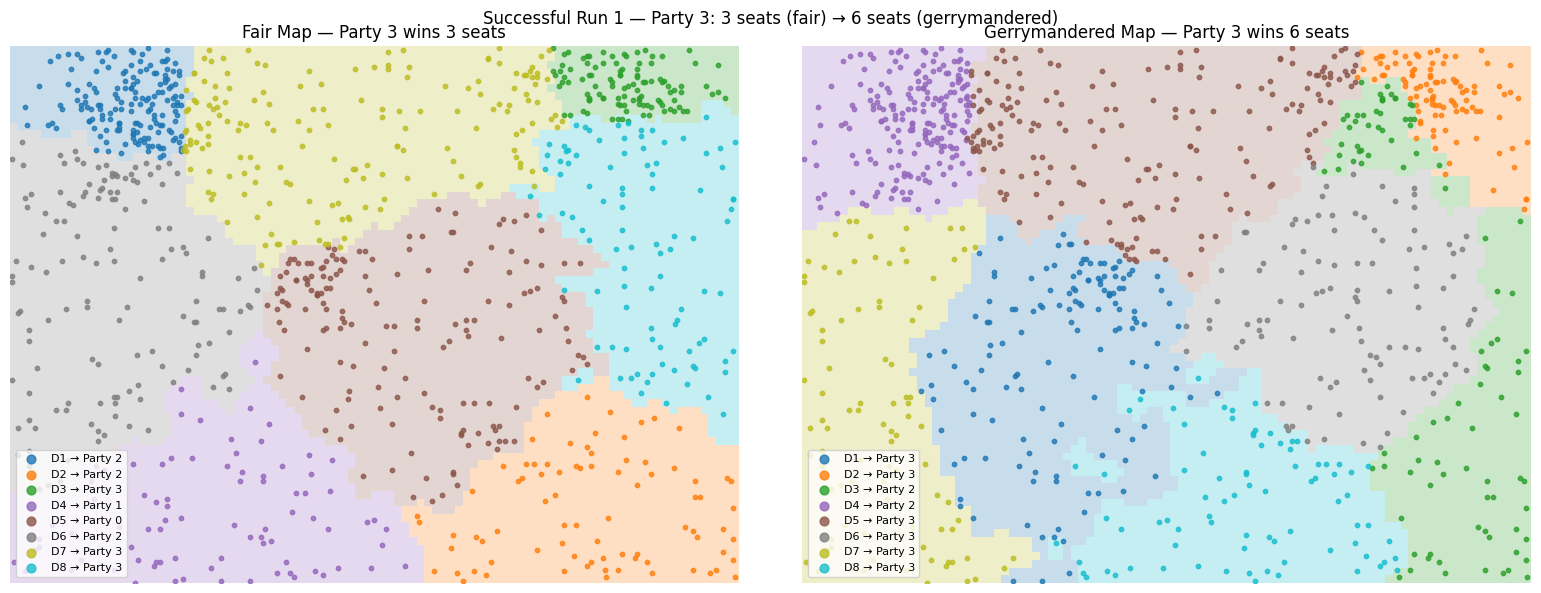

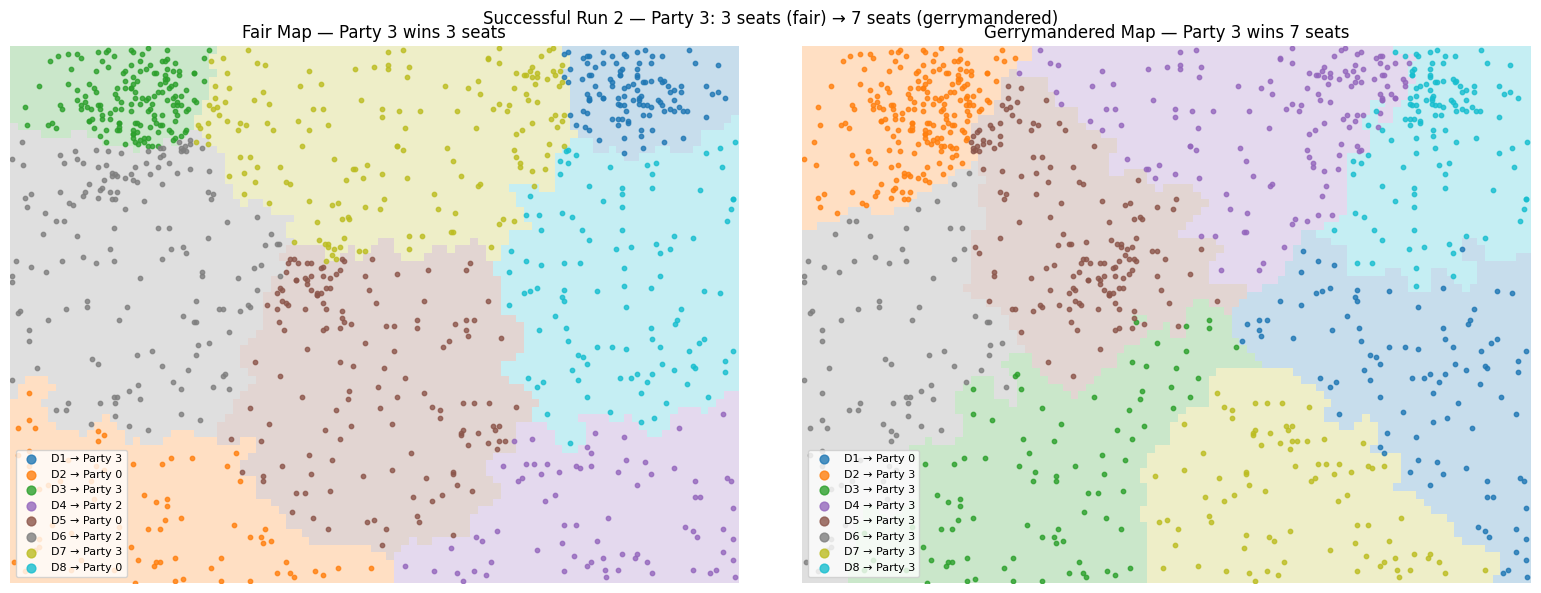

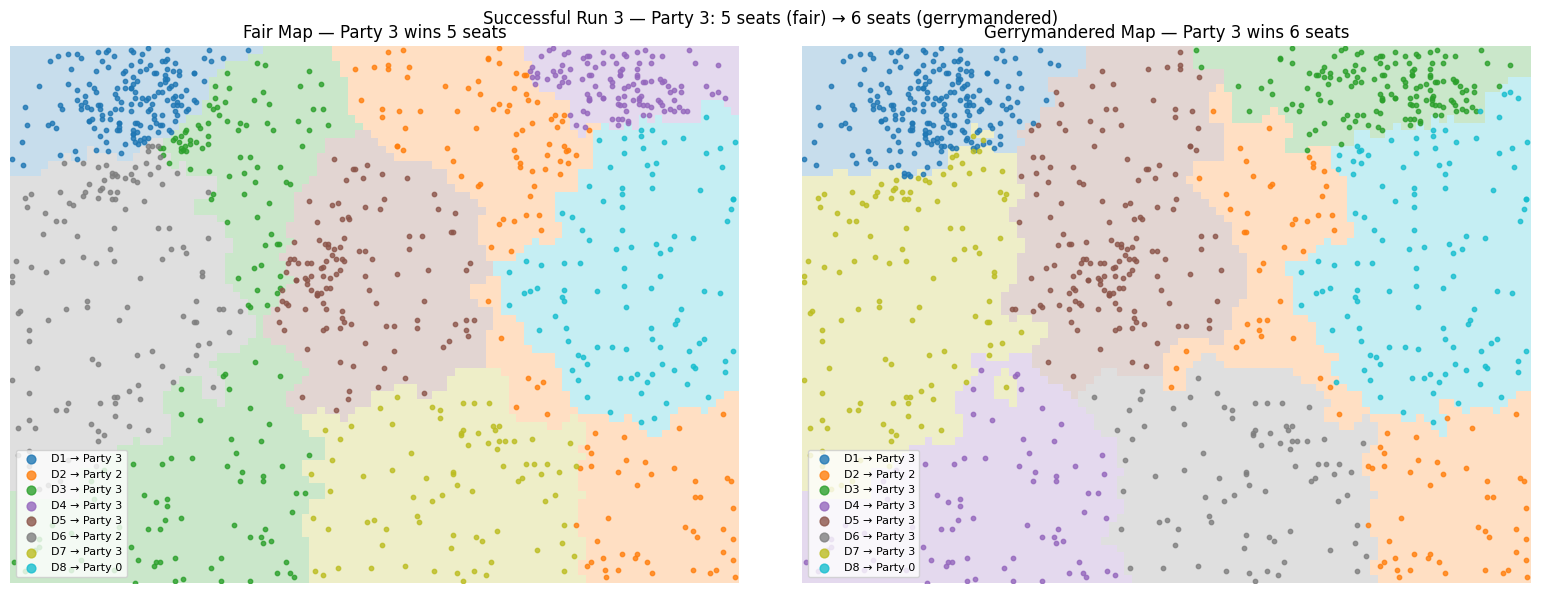

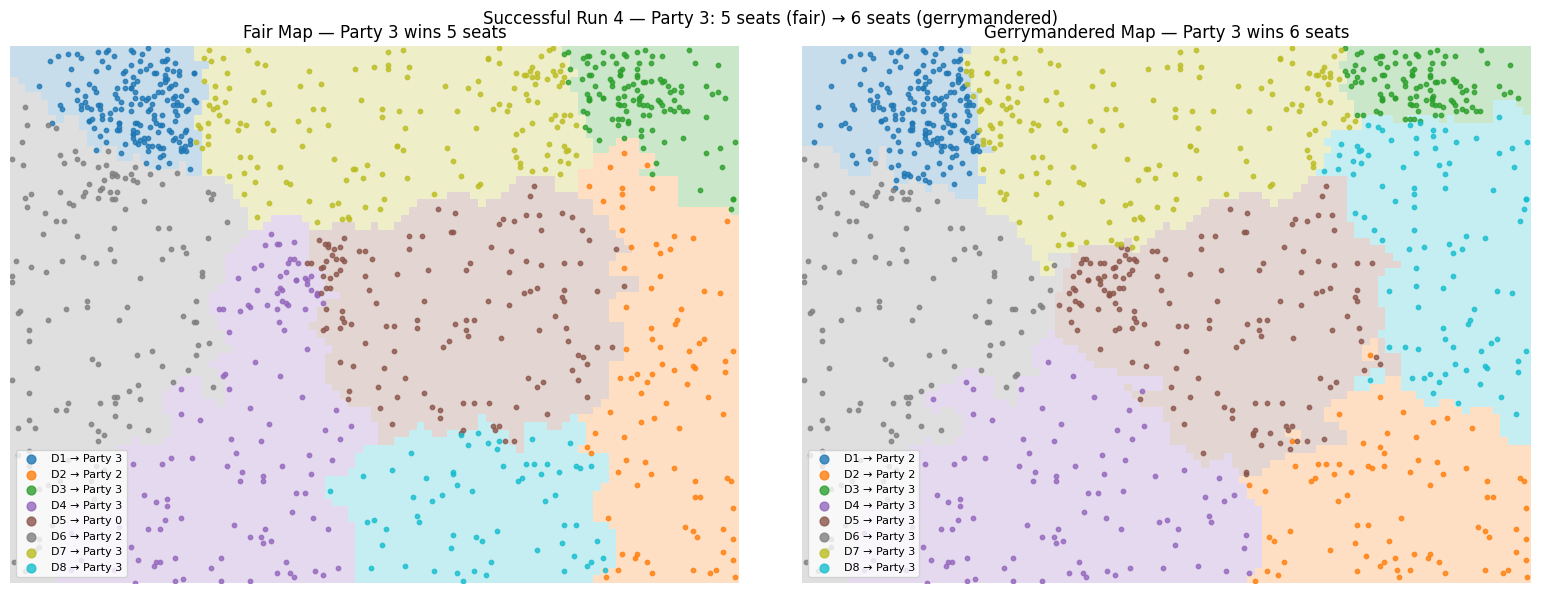

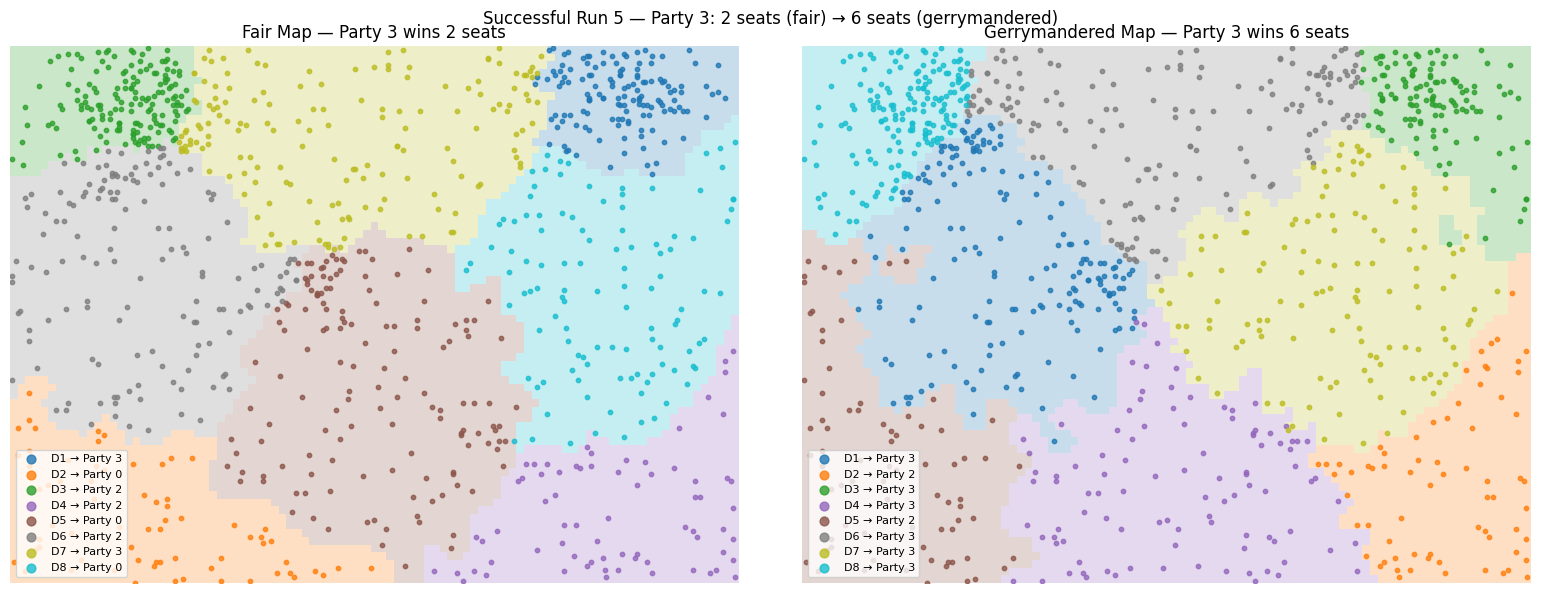

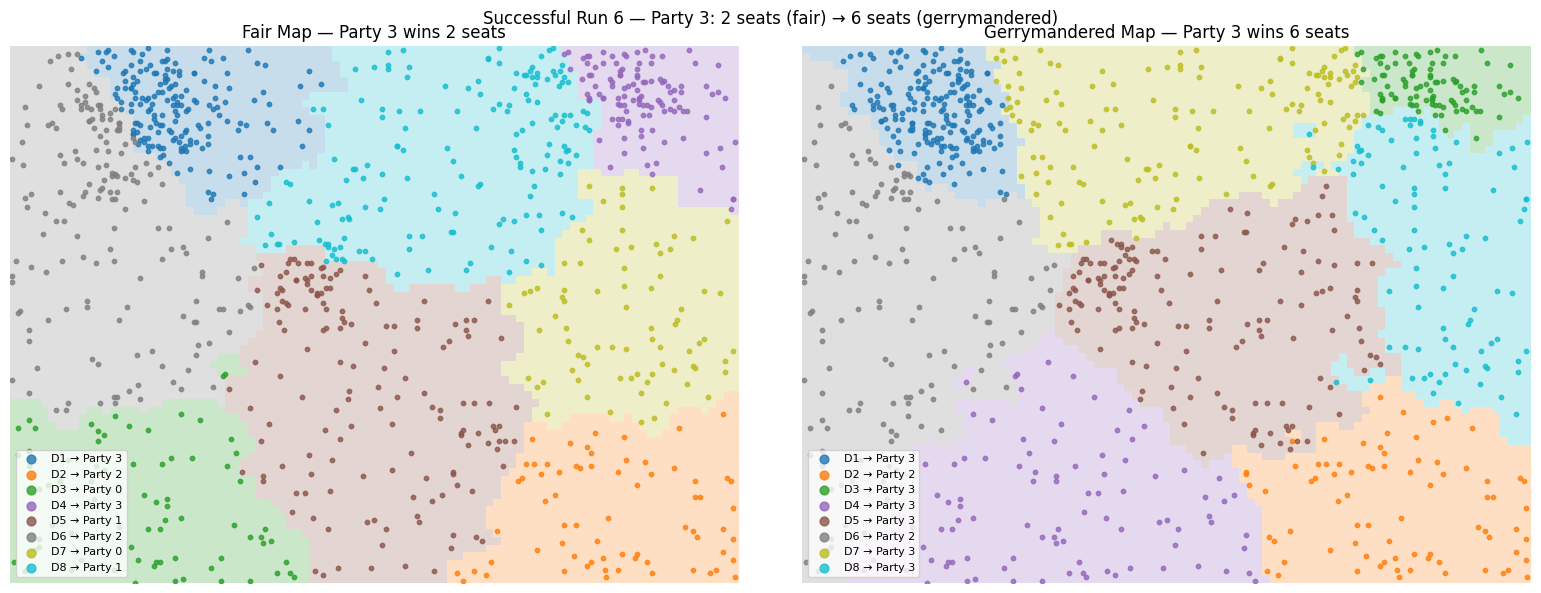

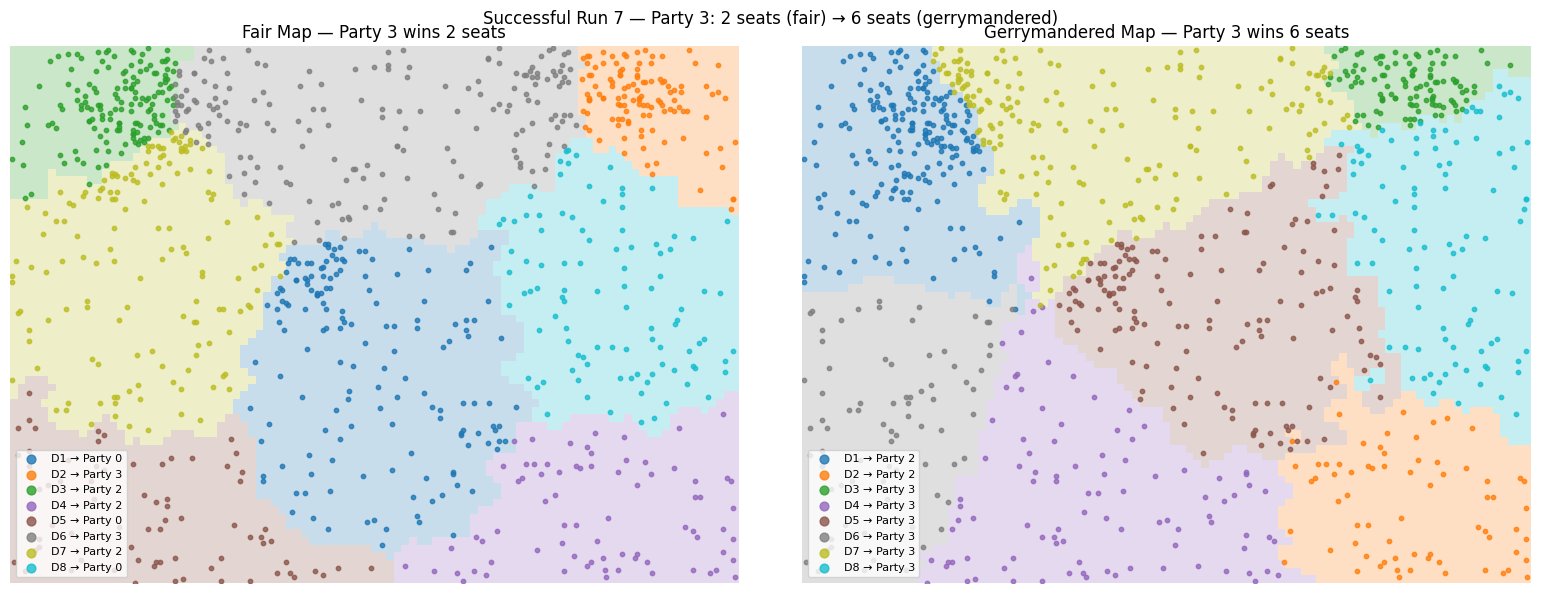

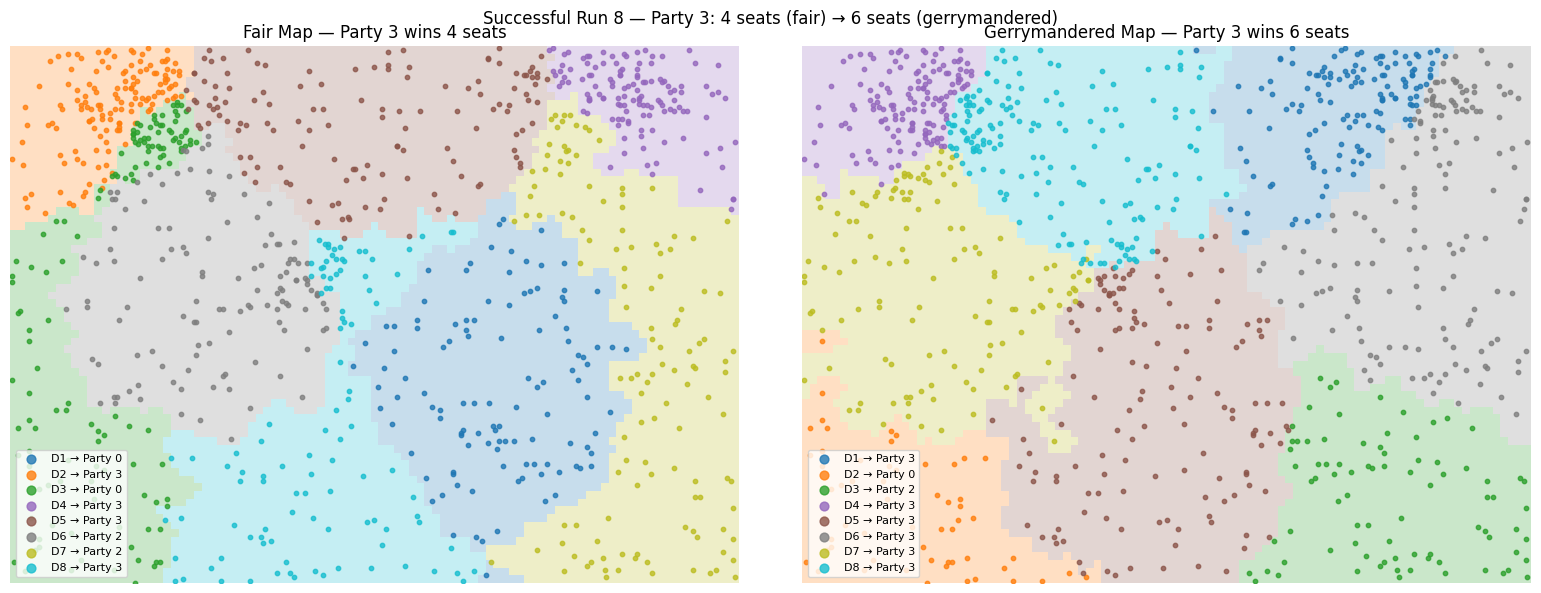

In [25]:
# Show the last 3 runs — change the number to whatever you want
plot_maps(10, all_starting_labels, all_gerrymandered_labels,
          voters, voter_parties, party_colors, PARTY_IDS, NUM_DISTRICTS)

In [26]:
# Run this after Phase 1 to diagnose
print("\n--- DIAGNOSTIC ---")
print(f"NUM_PARTIES: {NUM_PARTIES}")
print(f"PARTY_IDS: {PARTY_IDS}")
print(f"PARTY_BIAS: {PARTY_BIAS}")
print(f"Unique voter parties: {np.unique(voter_parties)}")
print(f"Voter party counts: {np.bincount(voter_parties)}")

# Check one run's district counts
sample_labels = all_starting_labels[0]
sample_counts = count_votes(sample_labels)
print("\nSample district vote counts (Run 1):")
for d_idx, counts in enumerate(sample_counts):
    winner = max(counts, key=counts.get)
    print(f"  District {d_idx+1}: {counts} → Winner: {winner}")

print(f"\nFair seat counts across all runs: {fair_seat_counts}")
print(f"Baseline seats: {baseline_seats}")


--- DIAGNOSTIC ---
NUM_PARTIES: 4
PARTY_IDS: ['Party 0', 'Party 1', 'Party 2', 'Party 3']
PARTY_BIAS: [0.25, 0.25, 0.25, 0.25]
Unique voter parties: [0 1 2 3]
Voter party counts: [238 230 251 281]

Sample district vote counts (Run 1):
  District 1: {'Party 0': 37, 'Party 1': 31, 'Party 2': 47, 'Party 3': 47} → Winner: Party 2
  District 2: {'Party 0': 17, 'Party 1': 12, 'Party 2': 30, 'Party 3': 22} → Winner: Party 2
  District 3: {'Party 0': 19, 'Party 1': 29, 'Party 2': 23, 'Party 3': 35} → Winner: Party 3
  District 4: {'Party 0': 21, 'Party 1': 23, 'Party 2': 17, 'Party 3': 22} → Winner: Party 1
  District 5: {'Party 0': 49, 'Party 1': 38, 'Party 2': 31, 'Party 3': 46} → Winner: Party 0
  District 6: {'Party 0': 32, 'Party 1': 28, 'Party 2': 43, 'Party 3': 35} → Winner: Party 2
  District 7: {'Party 0': 39, 'Party 1': 46, 'Party 2': 37, 'Party 3': 47} → Winner: Party 3
  District 8: {'Party 0': 24, 'Party 1': 23, 'Party 2': 23, 'Party 3': 27} → Winner: Party 3

Fair seat counts ac

In [27]:
# ------------------------------------------------------------
# PAIRWISE AREA DIFFERENCES — GERRYMANDERED RESULTS
# ------------------------------------------------------------
pairwise_results = []
party_pairs = list(itertools.combinations(PARTY_IDS, 2))

for run_idx in range(len(all_step_curves)):
    current_curves = all_step_curves[run_idx]

    for p1, p2 in party_pairs:
        area_gap = compute_pairwise_area(current_curves[p1], current_curves[p2], NUM_DISTRICTS)
        pairwise_results.append({
            "Run": run_idx + 1,
            "Comparison": f"{p1} vs {p2}",
            "Area Gap": area_gap
        })

df_pairs = pd.DataFrame(pairwise_results)
print("\n--- PAIRWISE AREA DIFFERENCES (GERRYMANDERED) ---")
print(df_pairs.to_string(index=False))


--- PAIRWISE AREA DIFFERENCES (GERRYMANDERED) ---
 Run         Comparison  Area Gap
   1 Party 0 vs Party 1  0.016875
   1 Party 0 vs Party 2  0.019750
   1 Party 0 vs Party 3  0.030375
   1 Party 1 vs Party 2  0.024875
   1 Party 1 vs Party 3  0.029000
   1 Party 2 vs Party 3  0.025125
   2 Party 0 vs Party 1  0.018000
   2 Party 0 vs Party 2  0.017750
   2 Party 0 vs Party 3  0.024750
   2 Party 1 vs Party 2  0.010500
   2 Party 1 vs Party 3  0.027000
   2 Party 2 vs Party 3  0.019500
   3 Party 0 vs Party 1  0.014250
   3 Party 0 vs Party 2  0.015000
   3 Party 0 vs Party 3  0.028250
   3 Party 1 vs Party 2  0.010250
   3 Party 1 vs Party 3  0.014000
   3 Party 2 vs Party 3  0.018000
   4 Party 0 vs Party 1  0.020000
   4 Party 0 vs Party 2  0.014750
   4 Party 0 vs Party 3  0.025250
   4 Party 1 vs Party 2  0.016250
   4 Party 1 vs Party 3  0.025250
   4 Party 2 vs Party 3  0.028500
   5 Party 0 vs Party 1  0.030875
   5 Party 0 vs Party 2  0.023500
   5 Party 0 vs Party 3  0.0330

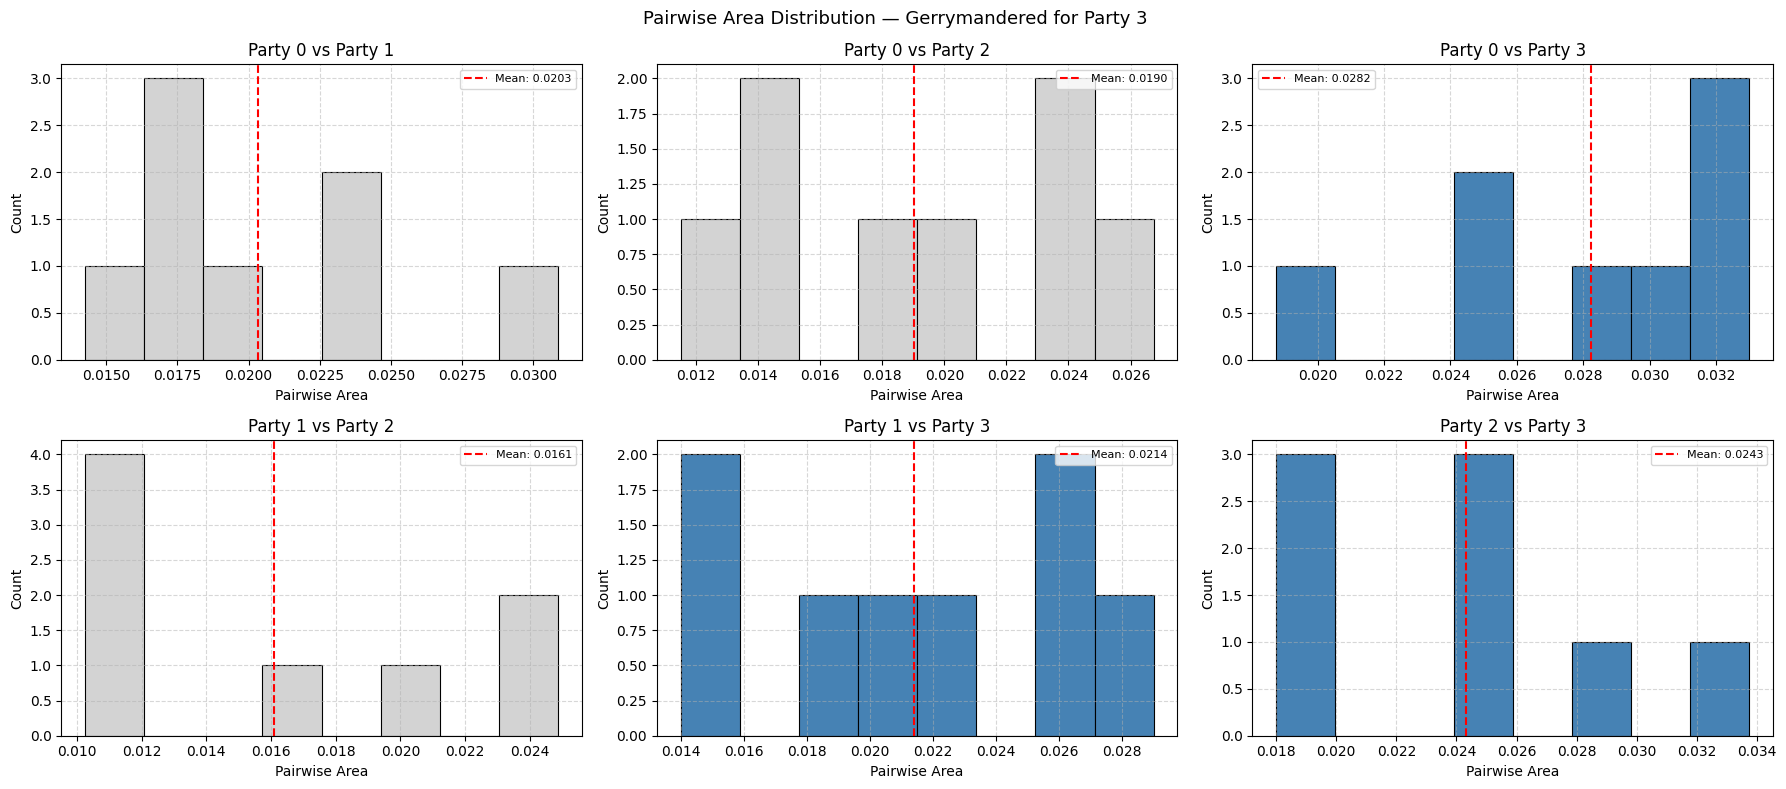

In [28]:
def plot_pairwise_area_histograms(df_pairs, PARTY_IDS, NUM_PARTIES, target_party):
    pairs = list(itertools.combinations(PARTY_IDS, 2))
    n_cols = int(np.ceil(np.sqrt(len(pairs))))
    n_rows = int(np.ceil(len(pairs) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()

    for i, (p1, p2) in enumerate(pairs):
        ax = axes[i]
        comparison = f"{p1} vs {p2}"
        values = df_pairs[df_pairs["Comparison"] == comparison]["Area Gap"].values
        color = "steelblue" if (p1 == target_party or p2 == target_party) else "lightgray"

        ax.hist(values, bins=min(10, len(values)), color=color,
                edgecolor="black", linewidth=0.8)
        ax.axvline(np.mean(values), color="red", linestyle="--",
                   linewidth=1.5, label=f"Mean: {np.mean(values):.4f}")
        ax.set_title(comparison)
        ax.set_xlabel("Pairwise Area")
        ax.set_ylabel("Count")
        ax.legend(fontsize=8)
        ax.grid(True, linestyle="--", alpha=0.5)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f"Pairwise Area Distribution — Gerrymandered for {target_party}", fontsize=13)
    plt.tight_layout()
    plt.show()

# ── Call after simulation ──
plot_pairwise_area_histograms(df_pairs, PARTY_IDS, NUM_PARTIES, TARGET_PARTY)

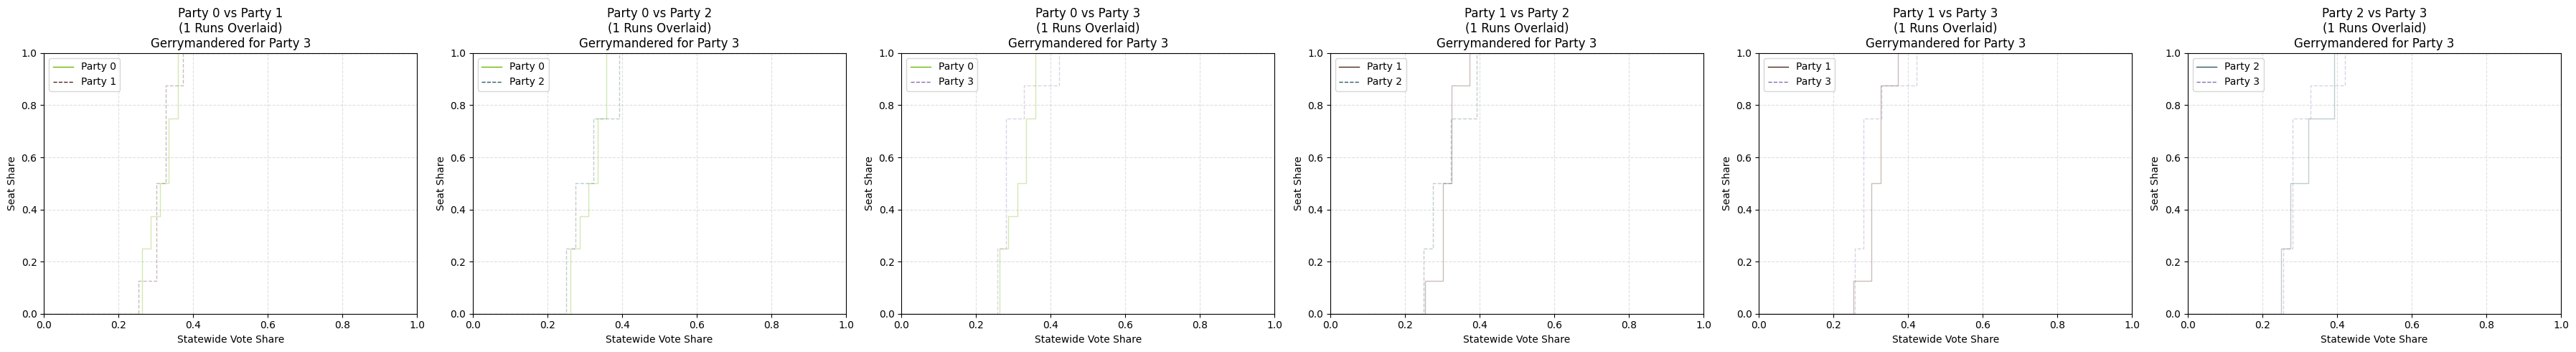

In [29]:
import itertools
import matplotlib.pyplot as plt
import numpy as np

def plot_pairwise_overlays(all_step_curves, PARTY_IDS, PARTY_COLORS, NUM_DISTRICTS,
                            num_runs_to_plot=20, title_suffix=""):
    """
    Creates one graph for each unique party pair.
    Each graph overlays multiple simulation runs to show the variance in bias.
    Works for both random and gerrymandered results.

    Usage (random):
        plot_pairwise_overlays(all_step_curves, PARTY_IDS, PARTY_COLORS, NUM_DISTRICTS)

    Usage (gerrymandered):
        plot_pairwise_overlays(all_step_curves, PARTY_IDS, PARTY_COLORS, NUM_DISTRICTS,
                               title_suffix="Gerrymandered for Party 1")
    """
    party_pairs = list(itertools.combinations(PARTY_IDS, 2))
    num_pairs = len(party_pairs)

    fig, axes = plt.subplots(1, num_pairs, figsize=(6 * num_pairs, 5), squeeze=False)

    runs_to_show = min(num_runs_to_plot, len(all_step_curves))

    for pair_idx, (party_a, party_b) in enumerate(party_pairs):
        ax = axes[0, pair_idx]

        for run_idx in range(runs_to_show):
            curve_a = all_step_curves[run_idx][party_a]
            curve_b = all_step_curves[run_idx][party_b]

            xa, ya = zip(*sorted(curve_a))
            xb, yb = zip(*sorted(curve_b))

            # Extend to full [0, 1] range
            xa = np.concatenate([[0], xa, [1.0]])
            ya = np.concatenate([[ya[0]], ya, [ya[-1]]])
            xb = np.concatenate([[0], xb, [1.0]])
            yb = np.concatenate([[yb[0]], yb, [yb[-1]]])

            ya_norm = np.array(ya) / NUM_DISTRICTS
            yb_norm = np.array(yb) / NUM_DISTRICTS

            label_a = party_a if run_idx == 0 else None
            label_b = party_b if run_idx == 0 else None

            ax.step(xa, ya_norm, where='post', color=PARTY_COLORS[party_a],
                    alpha=0.3, lw=1, label=label_a)
            ax.step(xb, yb_norm, where='post', color=PARTY_COLORS[party_b],
                    alpha=0.3, lw=1, label=label_b, linestyle='--')

        title = f"{party_a} vs {party_b}\n({runs_to_show} Runs Overlaid)"
        if title_suffix:
            title += f"\n{title_suffix}"
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Statewide Vote Share")
        ax.set_ylabel("Seat Share")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, linestyle="--", alpha=0.4)

        leg = ax.legend(loc='upper left')
        for lh in leg.legend_handles:
            lh.set_alpha(1)

    plt.tight_layout()
    plt.show()


# ── Gerrymandered simulation ──
plot_pairwise_overlays(all_step_curves, PARTY_IDS, PARTY_COLORS, NUM_DISTRICTS,
                        num_runs_to_plot=1, title_suffix=f"Gerrymandered for {TARGET_PARTY}")

In [ ]:
def compute_efficiency_gap(all_district_counts, PARTY_IDS, label=""):
    """
    Computes multi-party efficiency gap for each run.
    Gap = sum of (wasted_a - wasted_b)^2 for all unique pairs / total votes.
    """
    gap_rows = []

    for run_idx in range(len(all_district_counts)):
        district_counts = all_district_counts[run_idx]

        wasted_votes = {party: 0 for party in PARTY_IDS}
        total_votes = 0

        for district in district_counts:
            district_total = sum(district.values())
            total_votes += district_total

            sorted_parties = sorted(district.items(), key=lambda x: x[1], reverse=True)
            winner, winner_votes = sorted_parties[0]
            runner_up_votes = sorted_parties[1][1] if len(sorted_parties) > 1 else 0
            needed_to_win = runner_up_votes + 1

            for party in PARTY_IDS:
                votes = district[party]
                if party == winner:
                    wasted = max(0, votes - needed_to_win)
                else:
                    wasted = votes
                wasted_votes[party] += wasted

        squared_diff_sum = 0.0
        for p1, p2 in itertools.combinations(PARTY_IDS, 2):
            squared_diff_sum += (wasted_votes[p1] - wasted_votes[p2]) ** 2

        efficiency_gap_value = squared_diff_sum / total_votes

        gap_rows.append({
            "Run": run_idx + 1,
            "Efficiency_Gap": efficiency_gap_value,
            **{f"{party}_Wasted": wasted_votes[party] for party in PARTY_IDS}
        })

    df_gap = pd.DataFrame(gap_rows)

    title = f"EFFICIENCY GAP{' — ' + label if label else ''}"
    print(f"\n--- {title} ---")
    print(df_gap.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    print(f"\nMean Efficiency Gap: {df_gap['Efficiency_Gap'].mean():.4f}")
    print(f"Std  Efficiency Gap: {df_gap['Efficiency_Gap'].std():.4f}")

    return df_gap


# ── Random simulation ──
df_gap_random = compute_efficiency_gap(all_district_counts_random, PARTY_IDS, 
                                        label="Random Simulation")

# ── Gerrymandered simulation ──
df_gap_gerry = compute_efficiency_gap(all_district_counts, PARTY_IDS,
                                       label=f"Gerrymandered for {TARGET_PARTY}")